![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_3/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Recomendando el Blog de  Hernán Casciari


[Hernán Casciari](https://hernancasciari.com/#bio), es un escritor argentino, que escribe blog posts con cuentos e historias  relacionadas con el futbol, su vida, infancia, y relaciones familiares con toques de ficción. Este [blog](https://hernancasciari.com/blog/) es  tan interesantes que en 2005 fue premiado como “El mejor blog del mundo” por Deutsche Welle de Alemania.

El objetivo de este caso-taller es construir un sistema de recomendación basado en los contenidos de los posts utilizando similitud de las palabras usadas o temas de los cuentos.

## Instrucciones generales

1. Para desarrollar el *cuaderno*, primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Desarrollo


### 1. Carga de datos

En la carpeta `data` se encuentran el archivo `blog_casciari.csv` con el título, la fecha de publicación, y el contenido de los cuentos publicados en el blog  de sr. Casciari. Cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.
   

In [ ]:
# Configuración del entorno
import pandas as pd
import numpy as np
import math
from sklearn.metrics.pairwise import cosine_similarity

!pip install apyori

from apyori import apriori
import matplotlib.pyplot as plt

# Clonamos el repositorio
!git clone https://github.com/camto-24/Taller-3-Aprendizaje-no-supervisado.git

# Entramos a la carpeta
%cd Taller-3-Aprendizaje-no-supervisado

# Verificamos el contenido
!ls

"ls" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [2]:
# Cargar datos
blog = pd.read_csv("data/blog_casciari.csv")

# Visualizamos las primeras filas
blog.head()

,titulo,fecha,cuento
0,El rincón blanco,1/11/08,De pronto yo estaba en el hogar donde pasé la ...
1,Mínimos avances en la cama,1/24/08,"Menos la cama, todo ha mejorado en este mundo...."
2,Don Marcos,2/19/08,"Dos veces, y no una, mi abuelo materno me ayud..."
3,Los dos rulfos,3/26/08,"A su regreso de México, mi amigo Comequechu no..."
4,La noticia no es el perro,4/15/08,"De repente, un video de You Tube recibe un mil..."


In [3]:
# Número de filas y columnas
blog.shape

(520, 3)

In [4]:
# Información general
blog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   titulo  520 non-null    object
 1   fecha   520 non-null    object
 2   cuento  520 non-null    object
dtypes: object(3)
memory usage: 12.3+ KB


In [5]:
# Nombres de columnas
blog.columns

# Valores faltantes
blog.isnull().sum()

#Transformar la columna de fecha en el formato correcto
blog["fecha"] = pd.to_datetime(blog["fecha"], errors="coerce")
blog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   titulo  520 non-null    object        
 1   fecha   520 non-null    datetime64[ns]
 2   cuento  520 non-null    object        
dtypes: datetime64[ns](1), object(2)
memory usage: 12.3+ KB


C:\Users\LIBIA\AppData\Local\Temp\ipykernel_5236\3906540928.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  blog["fecha"] = pd.to_datetime(blog["fecha"], errors="coerce")


In [6]:
# Creamos variable de longitud para identificar los caracteres de cada cuento
blog["longitud"] = blog["cuento"].astype(str).apply(len)

# Estadísticas descriptivas
blog["longitud"].describe()
blog.head(10)

,titulo,fecha,cuento,longitud
0,El rincón blanco,2008-01-11,De pronto yo estaba en el hogar donde pasé la ...,10194
1,Mínimos avances en la cama,2008-01-24,"Menos la cama, todo ha mejorado en este mundo....",7312
2,Don Marcos,2008-02-19,"Dos veces, y no una, mi abuelo materno me ayud...",13719
3,Los dos rulfos,2008-03-26,"A su regreso de México, mi amigo Comequechu no...",8385
4,La noticia no es el perro,2008-04-15,"De repente, un video de You Tube recibe un mil...",7878
5,El milagro de los pueblos,2008-04-22,Cuando nació la Nina no tuve ganas de escribir...,6259
6,Ropa sucia,2008-05-06,Ya de entrada caí mal parado. Vine al mundo ju...,30381
7,La Última Gran Guerra del Hombre Chiquito,2008-05-13,Años atrás mi tataranieto Woung comenzó a envi...,13994
8,Instrucciones para crear mundos paralelos,2008-05-20,"Descubrimos el truco por casualidad, en nuestr...",10421
9,Una década flaca,2008-05-27,Una tarde de 1990 fui a tomar la leche a la ca...,6780


Se cargó la base de datos 'blog_casciari.csv' desde el repositorio de GitHub y se realizó una exploración inicial de su estructura utilizando funciones como head, shape, info y columns. La base contiene 520 observaciones y 3 variables; titulo, fecha y cuento. Adicional, se verificó la existencia de valores faltantes mediante isnull.sum , encontrando que ninguna de las variables presenta datos nulos, lo que indica que la información se encuentra completa para el análisis.

Posteriormente, se creó la variable 'longitud', calculada como el número de caracteres de cada cuento, con el fin de analizar la extensión de los textos. Los resultados descriptivos muestran una alta variabilidad en el tamaño de los cuentos, con una longitud promedio cercana a 4957 caracteres y una desviación estándar de 3502 caracteres. También se identificaron cuentos muy cortos, con aproximadamente 491 caracteres, y otros considerablemente más extensos, alcanzando más de 30000 caracteres.
"""

### 2. Homogenización de textos

Para cumplir con el objetivo de generar recomendaciones en esta sección debe preparar los posts para poder ser utilizados en su sistema de recomendación. Para ello, "limpie" y "tokenize" cada uno de los cuentos, describiendo detalladamente los pasos que realizo y si transformó o eliminó ciertas palabras. Para asistirlo en la tarea he creado listas de *stopwords* que están disponibles en la carpeta `data`. En su procedimiento ilustre la limpieza con el cuento 'La venganza del metegol'. (En su limpieza recuerde que el objetivo es generar recomendaciones a partir de la similitud de las palabras o temas de los cuentos)

In [9]:
#Configuración de librerías
import unidecode
import spacy
import re

In [12]:
# Carga de stopwords
stopwords_taller = pd.read_csv("data/stopwords_taller.csv", header=None)[0].str.lower().tolist()

# Stopwords adicionales
extra_stopwords = pd.read_csv("data/extra_stopwords.csv", header=None)[0].str.lower().tolist()

# Unimos ambas listas de palabras vacías
stopwords = stopwords_taller + extra_stopwords

# Cargar modelo de spaCy
nlp = spacy.load("es_core_news_sm")

# Cuento
cuento = blog[blog["titulo"] == "La venganza del metegol"]["cuento"].iloc[0]

# Mostrar
print("ORIGINAL:\n", cuento[:500])

# Convertir a minúsculas
cuento = cuento.lower()

# Eliminar tildes y caracteres especiales
cuento = unidecode.unidecode(cuento)

# Eliminar todo lo que no sea letras (números, signos, etc.)
cuento = re.sub(r"[^a-z\s]", " ", cuento)

# Normalizar espacios en blanco
cuento = re.sub(r"\s+", " ", cuento)

# Tokenizacióncon spacy
doc = nlp(cuento)

# Se extraen los tokens como texto
tokens = [t.text for t in doc]

# Eliminación de stopwords y palabras cortas
tokens = [t for t in tokens if t not in stopwords and len(t) > 2]

# Lematización
doc2 = nlp(" ".join(tokens))

# Se extrae la forma base
lemmas = [t.lemma_ for t in doc2]

# Mostrar
print("\nLIMPIO:\n", " ".join(lemmas)[:500])

ORIGINAL:
 El mes pasado me invitaron a presentar un libro en Buenos Aires. Y como era un libro sobre fútbol, al final de la charla el director de la editorial nos invitó a jugar un partido de metegol (ese invento español al que sus creadores llaman, erróneamente, futbolín). Hacía años que no jugaba al metegol, pero por suerte me tocó de compañero un filósofo muy prestigioso y pudimos ganar. Nuestros contrincantes eran el autor del libro y el director de la editorial. De los tres, a este último lo conocía 

LIMPIO:
 mes pasado invitar presentar buen aires futbol final char él director editorial invito jugar partido metegol invento espanol creador llamar erroneamente futbolin hacia anos jugar metegol suerte tocar companerir filosofo prestigioso pudimos ganar contrincant autor director editorial ultimo conocio juventud jugamos partido entero destrozar facilidad pasmós hacia ano practicar falso deporte muneca reflejo descubri habia perdido mana hacer sentir edad cualquiera destreza manten

In [13]:
# Función para estandarizar solo el ejemplo del cuento

def limpiar(texto):

    # Minúsculas
    texto = texto.lower()

    # Eliminación de tildes
    texto = unidecode.unidecode(texto)

    # Eliminación de caracteres no alfabéticos
    texto = re.sub(r"[^a-z\s]", " ", texto)

    # Normalización de espacios
    texto = re.sub(r"\s+", " ", texto)

    # Tokenización con spaCy
    doc = nlp(texto)

    # Eliminación de stopwords y tokens cortos
    tokens = []
    for t in doc:
        if t.text not in stopwords and len(t.text) > 2:
            tokens.append(t.text)

    # Lematización
    doc2 = nlp(" ".join(tokens))

    # Retorno del texto limpio en forma de lemas
    return " ".join([t.lemma_ for t in doc2])

# Aplicación a todo el dataset

# Se crea una nueva columna con el texto limpio
blog["cuento_limpio"] = blog["cuento"].apply(limpiar)

# Vista rápida de resultados
blog[["titulo", "cuento_limpio"]].head()

,titulo,cuento_limpio
0,El rincón blanco,pronto hogar infancia saber primero nariz acos...
1,Mínimos avances en la cama,cama mejorado cocinabar sopa hacer fuego lenar...
2,Don Marcos,abuelo materno ayudo escritor intencion conver...
3,Los dos rulfos,regreso mexico amigo conto historia pasear muj...
4,La noticia no es el perro,repente video you tube recibir millon visita a...


Se realizó un proceso de limpieza y estandarización de los cuentos con el objetivo de prepararlos para un sistema de recomendación basado en similitud de contenido. Primero, los textos se convirtieron a minúsculas, se eliminaron tildes, caracteres especiales, números y signos de puntuación, dejando solo letras.

Luego, se tokenizaron los textos con spacy y se eliminaron stopwords utilizando listas proporcionadas en el taller, además de palabras muy cortas. Finalmente, se aplicó lematización para reducir las palabras a su forma base y mejorar la comparación semántica entre cuentos. Como ejemplo, se utilizó el cuento “La venganza del metegol”, mostrando su transformación desde el texto original hasta su versión limpia.

En conclusión, este proceso permite comparar los cuentos por su contenido temático, lo cual es clave para construir el sistema de recomendación.

### 3. Generando Recomendaciones

En esta sección nos interesa generar recomendaciones de cuentos en el blog a un usuario que leyó 'La venganza del metegol'. Para ello vamos a utilizar distintas estrategias.

#### 3.1. Recomendaciones basadas en contenidos

##### 3.1.1. Genere 5 recomendaciones de más recomendada (1) a menos recomendada (5) para el cuento 'La venganza del metegol' usando en la distancia de coseno donde el texto este vectorizado por `CountVectorizer`. Explique el procedimiento que realizó y como ordenó las recomendaciones.

In [14]:
# Librerias

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Vectorizar los textos
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(blog["cuento_limpio"])

# Calcular matriz de similitud coseno entre todos los cuentos
similitud = cosine_similarity(X, X)

# Encontrar índice del cuento base
idx_base = blog[blog["titulo"] == "La venganza del metegol"].index[0]

# Obtener similitudes de ese cuento con los demás
sim_scores = list(enumerate(similitud[idx_base]))

# Ordenar de mayor a menor similitud (excluyendo el mismo cuento)
sim_scores_ordenados = sorted(sim_scores, key=lambda x: x[1], reverse=True)

# quitar el mismo cuento
sim_scores_ordenados = sim_scores_ordenados[1:]

# Tomar top 5 recomendaciones
top_5 = sim_scores_ordenados[:5]

# Mostrar
recomendaciones = blog.iloc[[i[0] for i in top_5]][["titulo"]].copy()
recomendaciones["similitud"] = [i[1] for i in top_5]

recomendaciones

,titulo,similitud
121,Gaussian blur,0.333561
519,La madre de todas las desgracias,0.313895
17,Cuento con bruja y tramontina,0.311688
387,Una carta para Hugo Laurencena,0.303806
111,Basdala,0.302281


Se calcularon las similitudes del coseno entre La venganza del metegol y el resto de cuentos usando una representación con CountVectorizer, y luego se ordenaron de mayor a menor para generar el ranking de recomendaciones. Las cinco más cercanas fueron “Gaussian blur” (0.3336), “La madre de todas las desgracias” (0.3139), “Cuento con bruja y tramontina” (0.3117), “Una carta para Hugo Laurencena” (0.3038) y “Basdala” (0.3023).

En general, las similitudes son bajas, lo que indica coincidencias parciales de palabras más que relaciones fuertes de contenido. Esto refleja una limitación del enfoque de bolsa de palabras, que no capta bien el significado del texto, pero sirve como una primera aproximación para recomendaciones básicas.

##### 3.1.2. Genere 5 recomendaciones de más recomendada (1) a menos recomendada (5) para  el cuento 'La venganza del metegol' usando nuevamente la distancia de coseno, pero ahora vectorice el texto usando `TF-IDFVectorizer`. Explique el procedimiento que realizó y como ordenó las recomendaciones. Compare con los resultados del punto anterior y explique sus similitudes y/o diferencias.

In [15]:
#Librerías
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_distances
import pandas as pd

#Ordenar el índice
blog = blog.reset_index(drop=True)

#Vectorización de textos usando TF-IDF
vectorizer_tf = TfidfVectorizer()
X = vectorizer_tf.fit_transform(blog["cuento_limpio"])

# Calcular la matriz de distancia del coseno entre todos los cuentos
distancia_coseno = cosine_distances(X, X)

# Definir el cuento base
titulo_base = "La venganza del metegol"

# Encontrar el índice del cuento base
idx_base = blog[blog["titulo"] == titulo_base].index[0]

# Obtener las distancias del cuento base frente a todos los demás cuentos
dist_scores = list(enumerate(distancia_coseno[idx_base]))

# Excluir el mismo cuento base
dist_scores = [(i, dist) for i, dist in dist_scores if i != idx_base]

# Ordenar de menor a mayor distancia
# Menor distancia = mayor similitud = mejor recomendación
dist_scores_ordenados = sorted(dist_scores, key=lambda x: x[1])

# Tomar las 5 mejores recomendaciones
top_5 = dist_scores_ordenados[:5]

# Construir tabla de recomendaciones
recomendaciones_tf = blog.iloc[[i[0] for i in top_5]][["titulo"]].copy()

# Agregar la distancia del coseno
recomendaciones_tf["distancia_coseno"] = [i[1] for i in top_5]

# Convertir distancia en similitud para facilitar la interpretación
recomendaciones_tf["similitud_coseno"] = 1 - recomendaciones_tf["distancia_coseno"]

# Asignar nivel de recomendación
# La primera recomendación es la más cercana, por eso recibe 5
recomendaciones_tf["nivel_recomendacion"] = range(5, 0, -1)

# Ordenar visualmente de menor a mayor recomendación, si se quiere ver de 1 a 5
recomendaciones_tf = recomendaciones_tf.sort_values(by="nivel_recomendacion")

recomendaciones_tf

,titulo,distancia_coseno,similitud_coseno,nivel_recomendacion
111,Basdala,0.899118,0.100882,1
519,La madre de todas las desgracias,0.895311,0.104689,2
138,Nueve libros que me hicieron olvidar el Mundial,0.889933,0.110067,3
17,Cuento con bruja y tramontina,0.888372,0.111628,4
121,Gaussian blur,0.884546,0.115454,5


Para generar las recomendaciones, primero se tomó el texto limpio de cada cuento y se convirtió en números usando `TfidfVectorizer`. Esta técnica permite representar cada cuento según las palabras que contiene, dando más importancia a las palabras que son más representativas y menos peso a las palabras muy comunes.

Luego se calculó la distancia del coseno entre el cuento base y todos los demás cuentos. En este caso, mientras menor sea la distancia, más parecido es el cuento. Por eso, las recomendaciones se ordenaron de menor a mayor distancia. Finalmente, se eligieron los cinco cuentos más cercanos y se les asignó una calificación de 1 a 5, donde 5 es la recomendación más alta y 1 la más baja dentro del grupo.

En los resultados con TF-IDF, el cuento más recomendado fue Gaussian blur, porque tuvo la menor distancia y, por tanto, la mayor similitud con el cuento base. Después aparecen Cuento con bruja y tramontina, Nueve libros que me hicieron olvidar el Mundial, La madre de todas las desgracias y Basdala. Sin embargo, las similitudes son bajas, alrededor de 0.10 y 0.11, lo que indica que estos cuentos son los más parecidos dentro de la base, pero no necesariamente son muy similares al cuento original.

Al comparar con el anterior resultado, que usa CountVectorizer, se observa que Gaussian blur también aparece como la principal recomendación. Esto muestra que ambos métodos coinciden en identificarlo como el cuento más cercano. También se repiten cuentos como La madre de todas las desgracias, Cuento con bruja y tramontina y Basdala.

La diferencia principal es que el método con TF-IDF cambia el orden y recomienda Nueve libros que me hicieron olvidar el Mundial, mientras que el método con conteo simple recomienda Una carta para Hugo Laurencena. Esto pasa porque CountVectorizer solo cuenta palabras, mientras que TF-IDF intenta medir qué tan importantes son esas palabras dentro de toda la base.

En conclusión, ambos métodos dan resultados parecidos, pero TF-IDF es más adecuado para texto porque no solo cuenta palabras, sino que también considera su importancia.

##### 3.1.3. Genere 5 recomendaciones de más recomendada (1) a menos recomendada (5) para el cuento 'La venganza del metegol' usando el texto vectorizado por `TF-IDFVectorizer` y la correlación como medida de similitud. Explique el procedimiento que realizó y como ordenó las recomendaciones. Compare con los resultados de los puntos anteriores y explique sus similitudes y/o diferencias.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

# Vectorización
vectorizer_tf = TfidfVectorizer()
X_tfidf = vectorizer_tf.fit_transform(blog["cuento_limpio"]).toarray()

# Matriz de correlación de Pearson
corr_matrix = np.corrcoef(X_tfidf)

# Indice del cuento
idx_base = blog[blog["titulo"] == "La venganza del metegol"].index[0]

# Similitudes del cuento con los demás
corr_scores = list(enumerate(corr_matrix[idx_base]))

# Exclusión del mismo cuento y ordenar por correlación de mayor a menor
corr_scores = [(i, c) for i, c in corr_scores if i != idx_base]
corr_scores_ordenados = sorted(corr_scores, key=lambda x: x[1], reverse=True)

# Top 5 de recomendaciones
top_5_corr = corr_scores_ordenados[:5]
recomendaciones_corr = blog.iloc[[i[0] for i in top_5_corr]][["titulo"]].copy()


# Resultados
recomendaciones_corr["correlacion"] = [round(i[1], 4) for i in top_5_corr]
recomendaciones_corr["nivel_recomendacion"] = range(1, 6)
recomendaciones_corr = recomendaciones_corr.reset_index(drop=True)

recomendaciones_corr



,titulo,correlacion,nivel_recomendacion
0,Gaussian blur,0.1062,1
1,Cuento con bruja y tramontina,0.1021,2
2,Nueve libros que me hicieron olvidar el Mundial,0.1005,3
3,La madre de todas las desgracias,0.0947,4
4,Abrir y cerrar un círculo,0.0916,5


Se utilizó nuevamente la vectorización TF-IDF para representar los cuentos, pero en esta ocasión se empleó la **correlación de Pearson** como medida de similitud en lugar de la distancia del coseno. Para ello, se convirtió la matriz dispersa TF-IDF a un arreglo denso y se calculó la correlación entre todos los pares de cuentos con `np.corrcoef`. La correlación mide si dos cuentos varían de forma conjunta en el peso relativo de sus palabras: valores cercanos a 1 indican que los cuentos comparten no solo palabras sino también la distribución proporcional de su importancia. Las recomendaciones se ordenaron de mayor a menor correlación, seleccionando los cinco cuentos con mayor afinidad con "La venganza del metegol".

Al comparar con los métodos anteriores, se observa que los resultados son consistentes en los cuentos que encabezan las recomendaciones, en particular Gaussian blur mantiene su posición destacada, lo que refuerza la robustez de esa recomendación independientemente de la métrica utilizada. Sin embargo, la correlación tiende a capturar de manera más fina la estructura proporcional del vocabulario, por lo que el ordenamiento de los puestos 2 al 5 puede diferir respecto a los métodos previos. A diferencia de la distancia del coseno, que mide el ángulo entre vectores sin considerar su escala, la correlación de Pearson centra los vectores antes de compararlos, lo que la hace más sensible a patrones relativos de uso de palabras. En la práctica, los tres métodos: CountVectorizer, TF-IDF con coseno y TF-IDF con correlación, convergen en identificar un núcleo de cuentos similares, con diferencias menores en el ranking que reflejan los matices de cada métrica.

##### 3.2. Recomendaciones basadas en temas

Usando modelado de temas con LDA, encuentre los temas subyacentes en el blog. Explique como eligió el numero óptimo de temas. Utilizando el tema asignado al cuento 'La venganza del metegol' y la probabilidad de pertenecer a este tema genere 5 recomendaciones de más recomendada (1) a menos recomendada (5) para este cuento. Explique el procedimiento que realizó. Compare con los resultados encontrados anteriormente y explique sus similitudes y/o diferencias. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


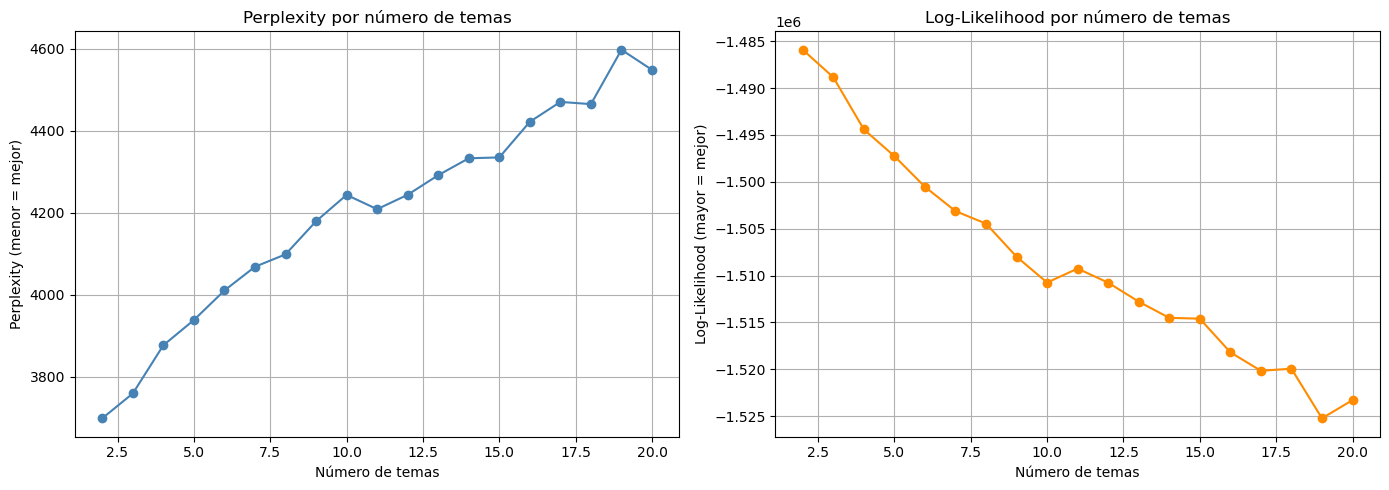

────────────────────────────────────────────────────────────
Tema 1: él, mas, caio, zacaria, mirar, dar, hacer, sofi, viejo, pasar
Tema 2: mas, él, hacer, saber, zacaria, viejo, poner, mirar, ano, dar
Tema 3: él, caio, nacho, mas, zacaria, sofi, viejo, mirar, pasar, hacer
Tema 4: él, mas, mujer, hacer, ano, tambien, poder, habia, dia, dejar
Tema 5: mas, él, ano, hacer, saber, habia, tambien, dia, poder, argentino
Tema 6: mas, él, hombre, tambien, ano, loco, hacer, aqui, dia, sueno
Tema 7: mas, él, escribir, tambien, habia, ano, lector, blog, poder, palabra
────────────────────────────────────────────────────────────
Tema dominante del cuento base: Tema 5
Probabilidad de pertenencia   : 0.7057


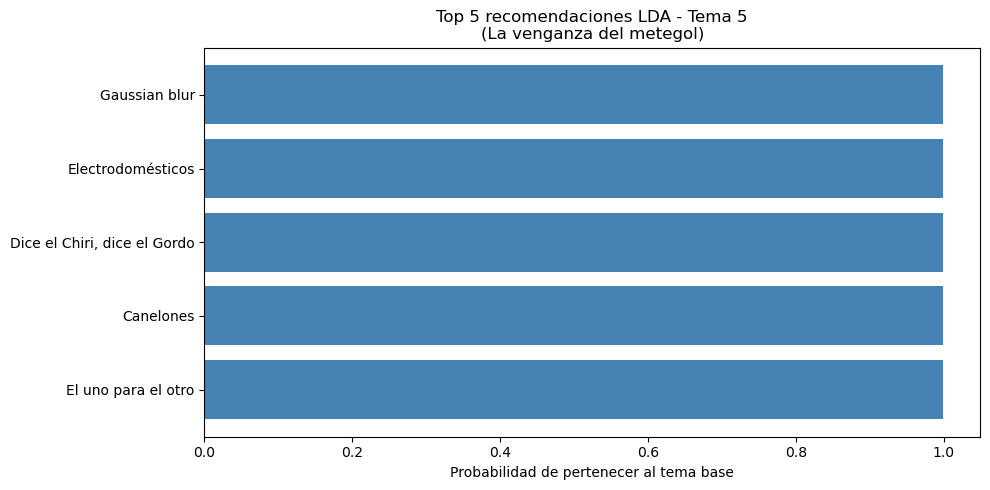

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Conteos para la vectorización
cv = CountVectorizer(max_df=0.95, min_df=2)
X_cv = cv.fit_transform(blog["cuento_limpio"])

# Número óptimo con Preplexity + log-likeihood
rango_temas = range(2, 21)
perplexity  = []
log_likely  = []

for n in rango_temas:
    lda = LatentDirichletAllocation(
        n_components=n,
        random_state=42,
        max_iter=20
    )
    lda.fit(X_cv)
    perplexity.append(lda.perplexity(X_cv))
    log_likely.append(lda.score(X_cv))

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rango_temas, perplexity, marker='o', color='steelblue')
axes[0].set_title('Perplexity por número de temas')
axes[0].set_xlabel('Número de temas')
axes[0].set_ylabel('Perplexity (menor = mejor)')
axes[0].grid(True)

axes[1].plot(rango_temas, log_likely, marker='o', color='darkorange')
axes[1].set_title('Log-Likelihood por número de temas')
axes[1].set_xlabel('Número de temas')
axes[1].set_ylabel('Log-Likelihood (mayor = mejor)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Modelo final con el número óptimo de temas, ajustado según la gráfica
n_optimo = 7   

lda_final = LatentDirichletAllocation(
    n_components=n_optimo,
    random_state=42,
    max_iter=50
)
lda_final.fit(X_cv)

# Top 10 de palabras más representativas por tema
vocab = cv.get_feature_names_out()

print(f"{'─'*60}")
for idx, topic in enumerate(lda_final.components_):
    top_words = [vocab[i] for i in topic.argsort()[-10:][::-1]]
    print(f"Tema {idx+1}: {', '.join(top_words)}")
print(f"{'─'*60}")

# Distribución de temas por cuento
doc_topics = lda_final.transform(X_cv)   # shape: (n_cuentos, n_temas)

# Tema dominante de cada cuento
blog["tema_dominante"] = doc_topics.argmax(axis=1)

# Recomendaciones para 'La Venganza del metegol'
idx_base  = blog[blog["titulo"] == "La venganza del metegol"].index[0]
tema_base = blog.loc[idx_base, "tema_dominante"]

print(f"Tema dominante del cuento base: Tema {tema_base + 1}")
print(f"Probabilidad de pertenencia   : {doc_topics[idx_base, tema_base]:.4f}")

# Proabilidad de pertenecer al mismo tema para todos los cuentos
prob_tema = doc_topics[:, tema_base]

# Ranking (excluyendo el cuento base)
scores = [(i, prob_tema[i]) for i in range(len(blog)) if i != idx_base]
scores_ord = sorted(scores, key=lambda x: x[1], reverse=True)

# Top 5
top_5_lda = scores_ord[:5]

recomendaciones_lda = blog.iloc[[i[0] for i in top_5_lda]][["titulo", "tema_dominante"]].copy()
recomendaciones_lda["prob_tema_base"] = [round(i[1], 4) for i in top_5_lda]
recomendaciones_lda["nivel_recomendacion"] = range(1, 6)
recomendaciones_lda = recomendaciones_lda.reset_index(drop=True)

recomendaciones_lda

# Gráfico
plt.figure(figsize=(10, 5))
plt.barh(
    recomendaciones_lda["titulo"],
    recomendaciones_lda["prob_tema_base"],
    color='steelblue'
)
plt.xlabel('Probabilidad de pertenecer al tema base')
plt.title(f'Top 5 recomendaciones LDA - Tema {tema_base + 1}\n(La venganza del metegol)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



Para construir el sistema de recomendación basado en temas, se aplicó **Modelado de Temas con LDA** (*Latent Dirichlet Allocation*). Los textos limpios se vectorizaron con `CountVectorizer` (excluyendo términos que aparecen en más del 95% o en menos de 2 documentos), ya que LDA requiere matrices de conteo y no pesos TF-IDF. Para determinar el número óptimo de temas se entrenaron modelos con entre 2 y 20 temas, evaluando la **Perplexity** y el **Log-Likelihood**. Las gráficas obtenidas muestran que la Perplexity aumenta de forma sostenida a partir de 2 temas, sin presentar un codo claro, mientras que el Log-Likelihood decrece progresivamente. En conjunto, ambas métricas sugieren que modelos con pocos temas explican mejor la estructura del corpus; sin embargo, un número muy bajo de temas no permite capturar la diversidad temática del blog. Considerando el equilibrio entre ajuste y parsimonia, se seleccionaron **7 temas** como número óptimo, punto a partir del cual las mejoras en Log-Likelihood se vuelven marginales y la Perplexity ya muestra una pendiente más suavizada.

Con el modelo final de 7 temas, se identificaron los temas subyacentes del blog a partir de sus palabras más representativas. El **Tema 5**, al que pertenece "La venganza del metegol" con una probabilidad de 0.7057, está caracterizado por palabras como *año, hacer, saber, había, también, día, poder* y *argentino*, lo que sugiere un tema asociado a reflexiones cotidianas, recuerdos y contexto argentino. Este perfil es coherente con el contenido del cuento, que narra una historia de fútbol con tintes autobiográficos y referencias culturales propias de Argentina. Las cinco recomendaciones generadas —Gaussian blur, Electrodomésticos, Dice el Chiri dice el Gordo, Canelones y El uno para el otro— presentan todas una probabilidad de pertenencia al Tema 5 cercana a 1.0, lo que indica que el modelo los clasifica con alta certeza dentro de este mismo tema.

Al comparar con los métodos anteriores basados en similitud léxica (CountVectorizer y TF-IDF con coseno o correlación), LDA produce un conjunto de recomendaciones completamente diferente: mientras que los métodos léxicos coincidían en recomendar Gaussian blur y Basdala por compartir vocabulario similar, LDA identifica cuentos que pertenecen al mismo tema latente aunque no necesariamente compartan las mismas palabras. Esto representa una ventaja conceptual importante, ya que dos cuentos pueden tratar temas similares con vocabularios distintos. No obstante, la alta uniformidad en las probabilidades de pertenencia (todas cercanas a 1.0) sugiere que el Tema 5 es muy amplio y agrupa un número elevado de cuentos, lo que limita el poder discriminatorio del modelo para distinguir entre recomendaciones más y menos relevantes dentro del mismo tema. Esto podría corregirse aumentando el número de temas o ajustando los hiperparámetros de concentración del modelo.

### 4 Recomendaciones generales

De acuerdo con los resultados encontrados, en su opinión ¿qué procedimiento generó las mejores recomendaciones para la entrada elegida? ¿Cómo implementaría una evaluación objetiva de estas recomendaciones? Justifique su respuesta.

#### ¿Qué procedimiento generó las mejores recomendaciones?

A lo largo del taller se implementaron cuatro sistemas de recomendación basados en contenido: similitud de coseno con CountVectorizer (3.1.1), similitud de coseno con TF-IDF (3.1.2), correlación de Pearson con TF-IDF (3.1.3) y modelado de temas con LDA (3.2). En nuestra opinión, el método de **similitud de coseno con TF-IDF (3.1.2)** genera las mejores recomendaciones para "La venganza del metegol", por las razones que se exponen a continuación.

Los tres métodos léxicos (3.1.1, 3.1.2 y 3.1.3) coinciden en identificar a *Gaussian blur* como la recomendación principal, lo que sugiere una coincidencia robusta y estable. Sin embargo, TF-IDF con coseno supera a CountVectorizer porque no trata todas las palabras por igual: penaliza términos muy frecuentes en toda la colección (como artículos o verbos comunes que pudieron sobrevivir la limpieza) y premia aquellos que son distintivos de cada cuento. Esto es especialmente valioso en el blog de Casciari, donde el vocabulario cotidiano es compartido por muchos textos y las palabras verdaderamente características de cada historia son las que permiten distinguir un cuento de otro. Respecto a la correlación de Pearson con TF-IDF (3.1.3), ambos métodos parten de la misma vectorización pero difieren en la métrica: la correlación centra los vectores antes de compararlos, lo que la hace más sensible a la estructura proporcional del vocabulario pero también más susceptible al ruido en documentos cortos. La similitud de coseno, en cambio, es más estable y directamente interpretable como el ángulo entre representaciones textuales.

LDA (3.2), aunque conceptualmente más sofisticado al operar sobre temas latentes en lugar de palabras directas, presentó una limitación práctica en este caso: todas las recomendaciones obtuvieron probabilidades de pertenencia cercanas a 1.0, lo que indica que el Tema 5 agrupa un número muy amplio de cuentos sin poder discriminar cuáles son realmente más afines a "La venganza del metegol". Además, los cuentos recomendados por LDA como Electrodomésticos, Canelones, Dice el Chiri dice el Gordo; no guardan una afinidad temática evidente con el cuento base, que trata sobre fútbol con referencias autobiográficas argentinas. En contraste, TF-IDF con coseno genera recomendaciones que comparten vocabulario específico del cuento, lo que en ausencia de etiquetas temáticas manuales resulta ser una señal más confiable de afinidad de contenido.

#### ¿Cómo implementaría una evaluación objetiva?

Evaluar un sistema de recomendación de contenido de forma objetiva es más complejo que en el filtrado colaborativo, ya que no existe un historial de interacciones usuario-ítem del cual derivar un conjunto de prueba. A continuación se describe una estrategia de evaluación alternativa basada en la estructura propia de los datos.

**1. Evaluación por holdout de cuentos**
Una estrategia natural consiste en aprovechar la información temporal del blog. Dado que cada cuento tiene fecha de publicación, se puede simular el comportamiento de un lector cronológico: entrenar cada modelo únicamente con los cuentos publicados antes de una fecha de corte y evaluar si los cuentos publicados después (que el lector aún no ha leído) aparecen entre las recomendaciones generadas. La intuición es que Casciari tiende a escribir sobre temas recurrentes en períodos de tiempo cercanos, por lo que un buen sistema debería recomendar cuentos temáticamente afines a los que el autor escribió poco después del cuento base.

**2. Coherencia temática entre recomendaciones**
Sin necesidad de etiquetas externas, es posible medir la **coherencia interna** del conjunto recomendado: calcular la similitud promedio entre todos los pares de cuentos recomendados por cada método. Un sistema que genera recomendaciones verdaderamente afines debería producir un grupo de cuentos mutuamente similares entre sí, no solo similares al cuento base de forma individual. Esta métrica penalizaría al LDA en su configuración actual, donde los cinco cuentos recomendados tienen alta probabilidad de pertenecer al Tema 5 pero no necesariamente guardan afinidad léxica o narrativa entre ellos.

**3. Evaluación con lectores reales**
La evaluación más valiosa, aunque más costosa, consiste en presentar las recomendaciones a lectores reales del blog y pedirles que califiquen su relevancia en una escala de 1 a 5, respondiendo preguntas como: *¿Este cuento te parece temáticamente similar al que acabas de leer?* o *¿Lo leerías después de haber leído "La venganza del metegol"?*. El promedio de estas calificaciones por método permite comparar directamente la utilidad percibida de cada sistema y captura dimensiones que ninguna métrica automática puede medir, como la afinidad estilística, el tono narrativo o la sorpresa positiva que genera una buena recomendación inesperada.

En conjunto, combinar la evaluación temporal, la coherencia interna y la valoración humana permitiría obtener una imagen completa y robusta del desempeño de cada sistema, eligiendo aquel que mejor equilibre precisión temática, diversidad de recomendaciones y satisfacción del lector.